# nbed library: Export to MRC
L. Houben, Weizmann Institute of Science
last updated January 2026

- Load a 4D STEM nanobeam diffraction data set.
  This script uses a data set that can be downloaded from https://doi.org/10.5281/zenodo.15212905
- Inspect a frame.
- Bin the data for faster processing
- Compensate residual descan shifts.
- Export to MRC format

In [1]:
import numpy as np
import numpy.matlib
#from objbrowser import browse
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pims
import trackpy as tp
# for animated view
import time
from IPython import display
%matplotlib inline
import os
# load nbed module and helper routines
# possibly installed under miniforge3/envs/py4Dstem/lib/python3.9/site-packages
import nbed
from nbed import ParabolaFit2D,bytscl

## Define filename, create class instance, load the data set, and display a single frame 
Currently supported formats: 
- PantaRhei .prz (default)
- EMPAD .raw
- DECTRIS Eiger

In [2]:
# Path definition and filename
path="/Volumes/externnvme/Scratch/260114-VishalSingh-newbatch-A1-Phln-COF30/NBED-001/"
filebasename="4D-STEM_Single_Image"
filesuffix="prz"
# binning factors
sbin=1 # spatial binning
qbin=1 # diffraction frame binning

In [3]:
# create an instance of the pyNBED module and load data
myset=nbed.pyNBED()
myset.LoadFile(path+filebasename+'.'+filesuffix)

pyNBED: Loading object descriptor: /Volumes/externnvme/Scratch/260114-VishalSingh-newbatch-A1-Phln-COF30/NBED-001/4D-STEM_Single_Image.prz
pyNBED: Loading data ...
        finished
pyNBED: array dimensions: (84, 78, 512, 512)
pyNBED: Preparing reciprocal space sampling grid


In [4]:
# There is a docstring for the methods in the pyNBED module, here is how you can display it
myset.LoadFile?

Signature: myset.LoadFile(fname, type='PantaRhei')
Docstring:
Load a 4D STEM dataset  

Parameters:
fname:   complete filename including path and suffix
type:    'PantaRhei' or 'EMPAD' [default: PantaRhei]

Returns:

void
File:      ~/miniforge3/envs/py4dstem/lib/python3.12/site-packages/nbed/classes/pyNBED.py
Type:      method

In [5]:
# Display a single frame at row 174, column 94
frame=myset.ShowFrame(i=174, j=94,Log=True, sd=6)

Range error. Check frame indices.


In [6]:
### Spatial Binning
myset.SpatialBinning?

Signature: myset.SpatialBinning(bin)
Docstring:
Spatial Binning

Binning of the first two dimensions x,y of the 4D STEM data (x,y,qx,qy)

Parameters:
bin:   binning factor (default: 2)

returns

nothing (the object data will be replaced)
File:      ~/miniforge3/envs/py4dstem/lib/python3.12/site-packages/nbed/classes/pyNBED.py
Type:      method

In [7]:
# Spatial Binning
if sbin > 1:
    myset.SpatialBinning(bin=sbin)

In [8]:
# Diffraction Frame Binning
if qbin > 1:
    myset.FrameBinning(bin=2)

## Find central diffraction peak locations and compensate the displacement
The data held by the class instance will be updated and hold the aligned frames. <br>
A second execution will display the residual displacements after correction with a second order polynomial.

locating strongest pixel in all frames ...
finished


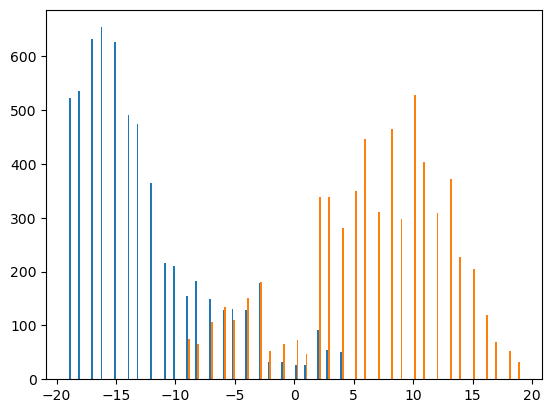

Displacement statistics along x, filtered for outliers (all indices):
Mean =  -13.78429947301472 ( -11.23015873015873 )
Max  =  -3 ( 19 )
Min  =  -19 ( -19 )
Displacement statistics along y, filtered for outliers (all indices):
Mean =  6.796656369253134 ( 5.464133089133089 )
Max  =  19 ( 19 )
Min  =  -8 ( -19 )


<Figure size 640x480 with 0 Axes>

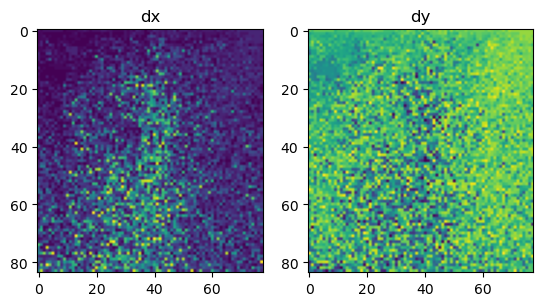

In [9]:
# obtain displacements
(dx,dy)=myset.DiffractionShift(reject_sd=2, searchradius=20)

(6552,)


<Figure size 640x480 with 0 Axes>

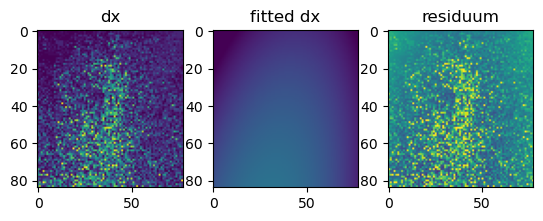

Residuum statistics dx-dxfit
Mean deviation:     2.997764513140121e-08
Max abs deviation:  34.57280961995086
Mean abs deviation: 5.054660337078306
(6552,)


<Figure size 640x480 with 0 Axes>

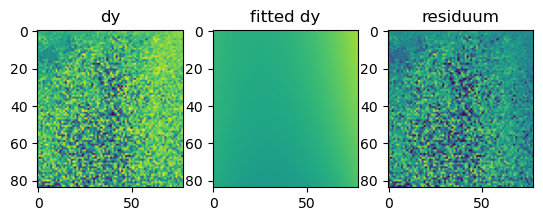

Residuum statistics dy-dyfit
Mean deviation:     9.432125920083307e-10
Max abs deviation:  24.56368542747007
Mean abs deviation: 5.537816537565133
finished


In [10]:
# compensate shifts pixel-wise
myset.CompensateShift(dx,dy)

locating strongest pixel in all frames ...
finished


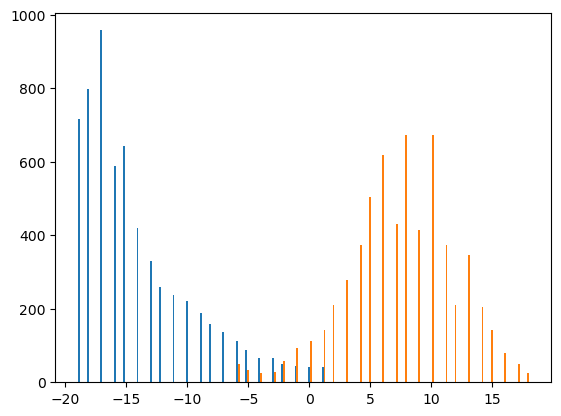

Displacement statistics along x, filtered for outliers (all indices):
Mean =  -15.085303746817024 ( -12.798992673992673 )
Max  =  -6 ( 19 )
Min  =  -19 ( -19 )
Displacement statistics along y, filtered for outliers (all indices):
Mean =  7.7128046562386325 ( 6.383394383394384 )
Max  =  17 ( 19 )
Min  =  -3 ( -19 )


<Figure size 640x480 with 0 Axes>

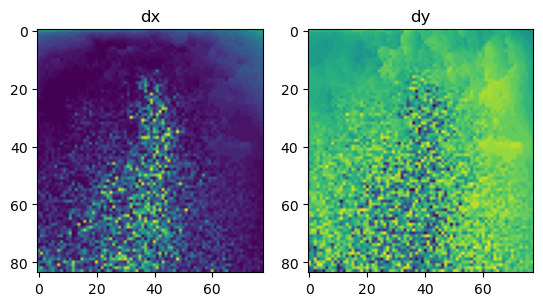

In [11]:
# check that the correction worked and display the residual displacement statistics 
# the residuum shows the com shift corrected for the low-order descan shift
# steps in the residuum are integer truncation remainders due to the pixel-wise shift
(dx,dy)=myset.DiffractionShift(reject_sd=2, searchradius=20)

## Create a virtual aperture image



In [12]:
# Create a virtual detector image
# this may take some time due to single-core processing
# the routine returns the mask on the diffraction frame and the corresponding virtual image
myset.VirtualApertureImage?

Signature:
myset.VirtualApertureImage(
    radius=[0, 10],
    offset=None,
    invert=False,
    mode=None,
)
Docstring:
Create a virtual detector image with a disk-like aperture

Parameters:
radius:    inner and outer radius of the aperture in pixels [default:[0,10]]
offset:    optional displacement from the center in pixels [default: None]
           offset=[20,100] shifts the aperture mask 20 pixels horizontally and 100 pixels vertically
invert:    invert the aperture mask, e.g. to create a dark-field image instead of a bright-field image
mode:      calculation mode, default is 'sum', options: 'sum','fluct','fluct_norm'
           'fluct'=variance across the mask, 'fluct_norm'=variance divided by mean value
   
Notes: 

the mask will span the range [iradius,oradius[
the computational effort is proportional to the number of pixels in the mask

Examples: 

BF detector - radius=[0,radius] of the bright field mask, invert=False
DF detector - radius=[0,100], invert=True
annular DF detec

In [13]:
# create a virtual detector image, here an annular dark-field image
(mask, vimage)=myset.VirtualApertureImage(radius=[70//qbin,100//qbin],offset=[0,0],invert=False,mode='sum')

<Figure size 640x480 with 0 Axes>

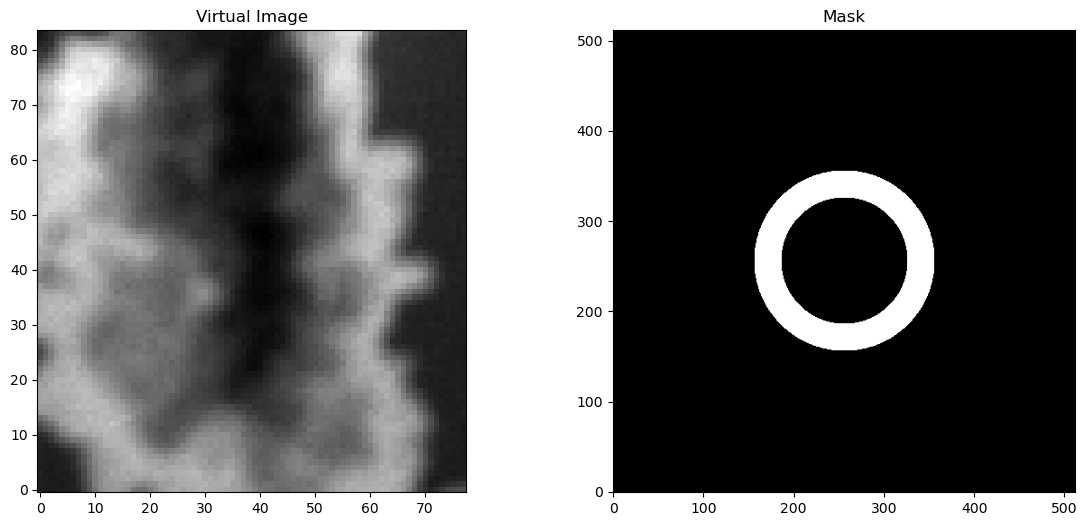

In [14]:
# plot the image
#dispimage=np.log(vimage)
dispimage=vimage
plt.figure()
#subplot(r,c) provide the no. of rows and columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# use the created array to output your multiple images. In this case I have stacked 4 images vertically
ax1.imshow(bytscl(dispimage,vmin=np.mean(dispimage)-3*np.std(dispimage),vmax=np.mean(dispimage)+3*np.std(dispimage)),cmap='gray',origin="lower") 
ax1.set_title('Virtual Image')
ax2.imshow(mask,cmap='gray',origin="lower")
ax2.set_title('Mask')
plt.show()

In [16]:
myset.StackExport(format="mrc")

pyNBED: Wrote  /Volumes/externnvme/Scratch/260114-VishalSingh-newbatch-A1-Phln-COF30/NBED-001/4D-STEM_Single_Image-78x84_512x512_6552frames_float32.mrc
